scipy.datasets not available - using random matrix as fallback
Image shape: (512, 512)
Image dtype: float64
Pixel value range: 0.000844 to 254.999748


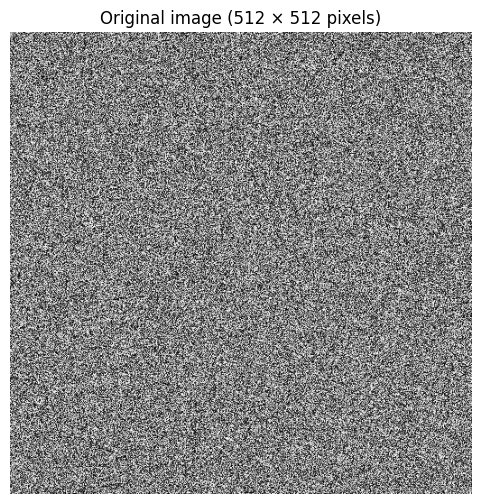

In [10]:
# Here we are trying to build an image compression algorithm using svd

# Loading the image
from matplotlib import image as mpimg
from matplotlib.colors import LinearSegmentedColormap
import urllib.request
import numpy as np
import matplotlib.pyplot as plt


# Use a built-in image from scipy if available, otherwise download a sample
try:
    from scipy.datasets import face
    img = face(gray=True)
    print("Using scipy's built-in image (face)")
except ImportError:
    # Fallback: use any URL or local image
    print("scipy.datasets not available - using random matrix as fallback")
    np.random.seed(0)
    img = np.random.rand(512, 512) * 255
    img = np.round(img,6)

print("Image shape:", img.shape)
print("Image dtype:", img.dtype)
print("Pixel value range:", img.min(), "to", img.max())

# Display the original
plt.figure(figsize=(8, 6))
plt.imshow(img, cmap='gray')
plt.title(f'Original image ({img.shape[0]} × {img.shape[1]} pixels)')
plt.axis('off')
plt.show()

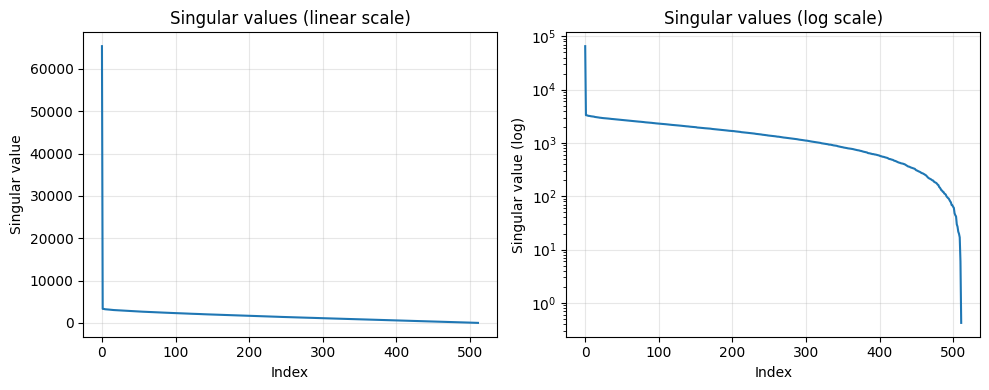

In [13]:
# Comouting svd for image

# Converting to float for SVD computation
img_float = img.astype(float)

U, sv, Vt = np.linalg.svd(img_float, full_matrices=False)

# Visualizing the singular values distribution


plt.figure(figsize=(10, 4))

# Linear scale
plt.subplot(1, 2, 1)
plt.plot(sv)
plt.title('Singular values (linear scale)')
plt.xlabel('Index')
plt.ylabel('Singular value')
plt.grid(True, alpha=0.3)

# Log scale — reveals the long tail
plt.subplot(1, 2, 2)
plt.semilogy(sv)
plt.title('Singular values (log scale)')
plt.xlabel('Index')
plt.ylabel('Singular value (log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

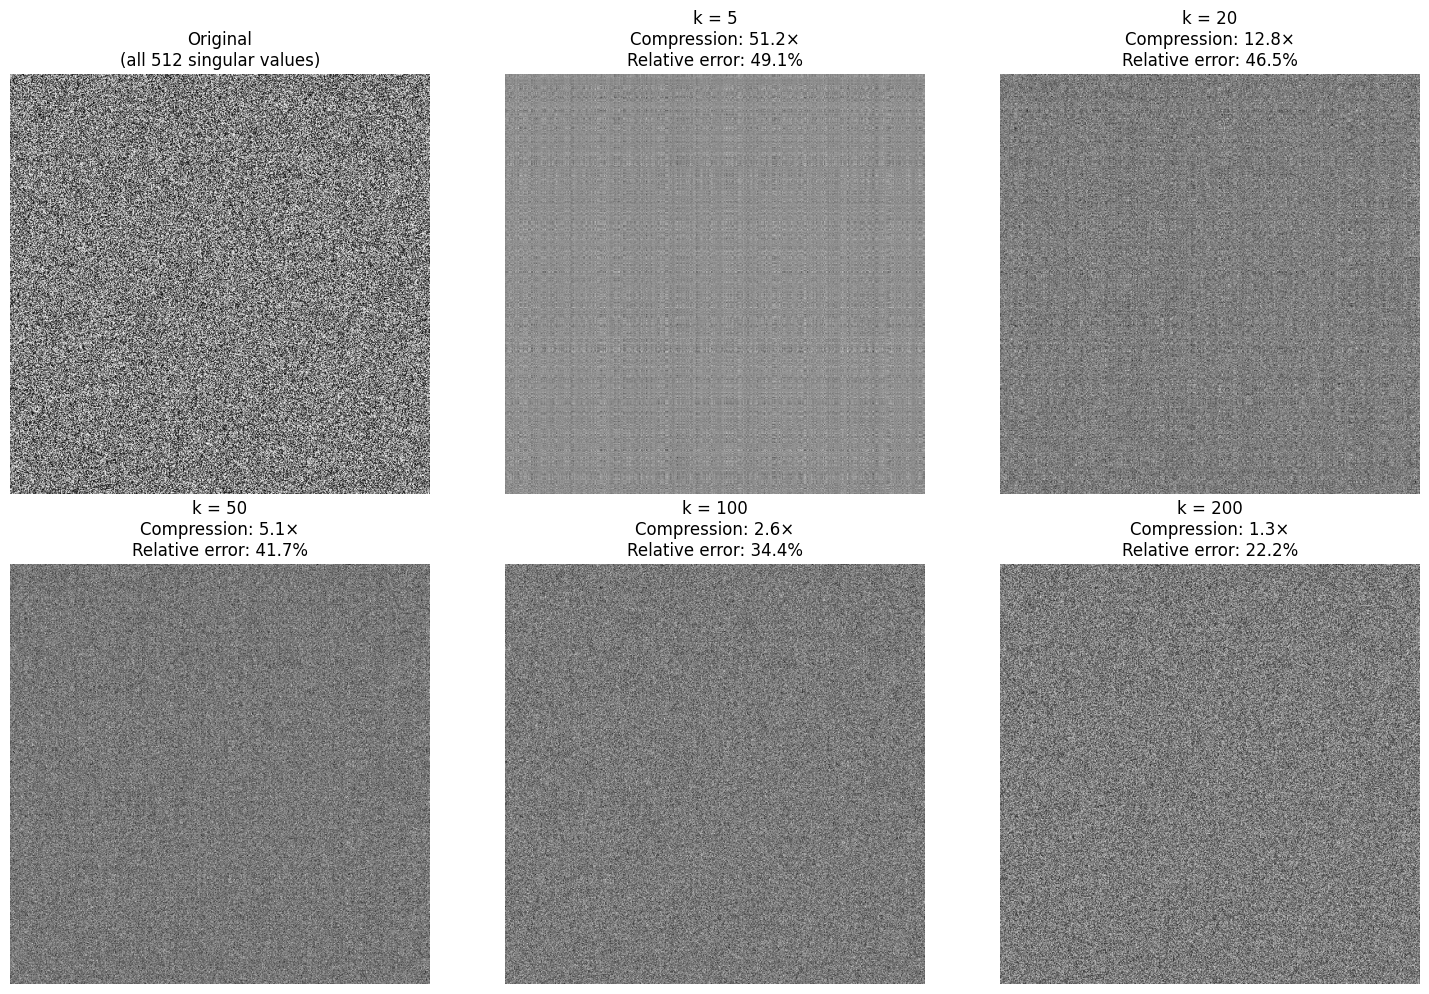

In [17]:
# Now let us take random k values and reconstruct image fro different of them


def rank_k_image(U, sv, Vt, k):
    """Reconstruct image using only top-k singular values."""
    return U[:, :k] @ np.diag(sv[:k]) @ Vt[:k, :]


k_values = [5, 20, 50, 100, 200]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Show the original first
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f'Original\n(all {len(sv)} singular values)')
axes[0].axis('off')

# Show each rank-k approximation
for idx, k in enumerate(k_values, start=1):
    img_k = rank_k_image(U, sv, Vt, k)
    axes[idx].imshow(img_k, cmap='gray')
    
    # Compute compression ratio
    m, n = img.shape
    original_size = m * n
    compressed_size = k * (m + n + 1)
    compression = original_size / compressed_size
    
    # Compute error
    error = np.linalg.norm(img - img_k, 'fro') / np.linalg.norm(img, 'fro')
    
    axes[idx].set_title(f'k = {k}\nCompression: {compression:.1f}×\nRelative error: {error:.1%}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

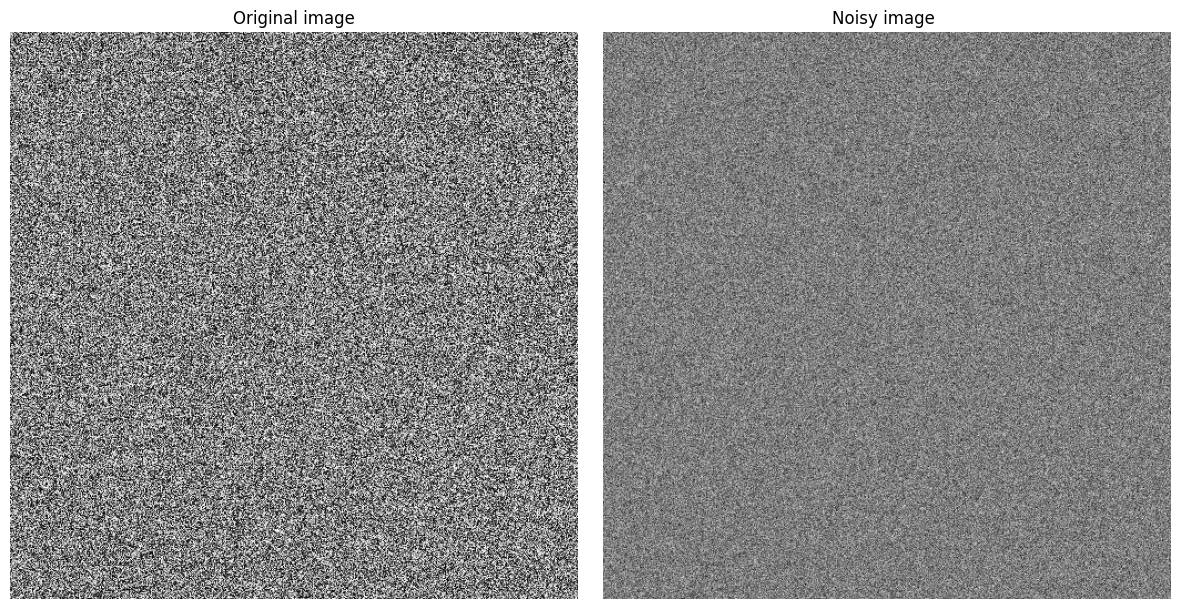

In [27]:
# Now let us add nosie to the image and visualize the original and noisy image

np.random.seed(0)
# noise = np.random.normal(0, 25, img_float.shape)  
noise = np.random.normal(0, 80, img_float.shape)
img_noisy = img_float + noise


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_float, cmap='gray')
axes[0].set_title('Original image')
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray')
axes[1].set_title('Noisy image ')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [28]:
# Now let us compute the svd and print singualr values for both original and noisy image

U_n, sv_n, Vt_n = np.linalg.svd(img_noisy, full_matrices=False)

print("Top 10 singular values of noisy image:", sv_n[:10].astype(int))
print("Bottom 10 singular values of noisy image:", sv_n[-10:].astype(int))

# Compare to original
print("\nTop 10 singular values of original image:", sv[:10].astype(int))
print("Bottom 10 singular values of original image:", sv[-10:].astype(int))


# The nosiy image raised the floor of the singular values but the overall distribution of singular values 
# look soimilar to the original image the dominant patterns are all at the start

Top 10 singular values of noisy image: [65440  4897  4803  4791  4787  4715  4701  4685  4642  4625]
Bottom 10 singular values of noisy image: [68 62 59 47 40 32 22 15 10  0]

Top 10 singular values of original image: [65346  3314  3296  3282  3227  3216  3206  3178  3163  3150]
Bottom 10 singular values of original image: [47 44 41 29 26 21 19 16  5  0]


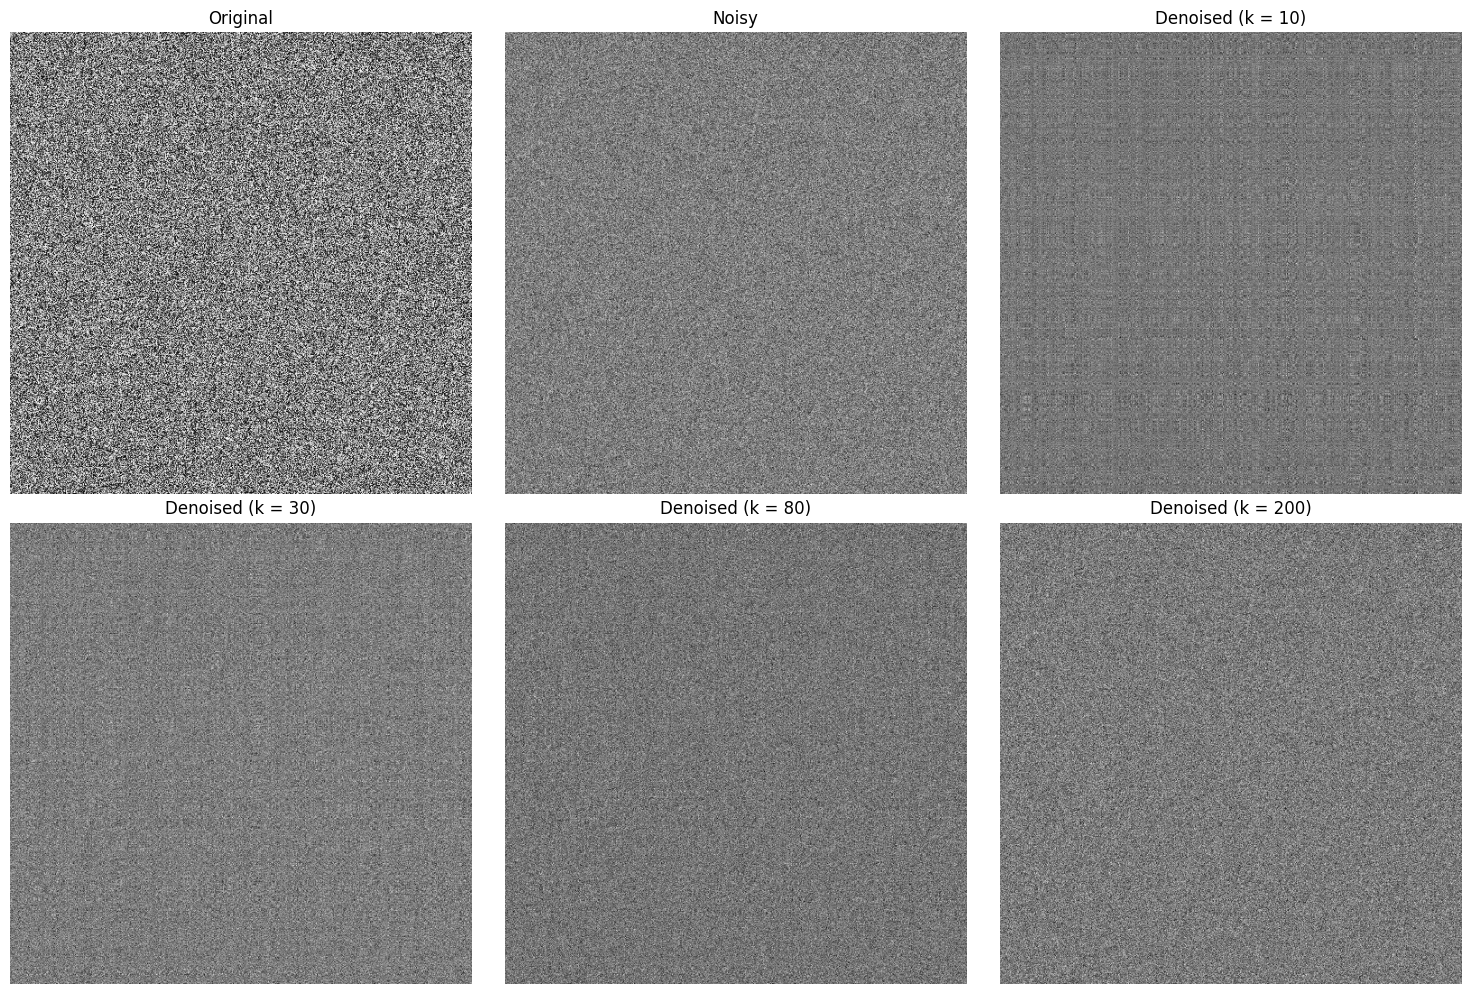

In [29]:
# Now let us look for the different denoisy image version by picking different k value


def reconstruct_with_k(U, sv, Vt, k):
    return U[:, :k] @ np.diag(sv[:k]) @ Vt[:k, :]


k_values = [10, 30, 80, 200]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

axes[0].imshow(img_float, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_noisy, cmap='gray')
axes[1].set_title('Noisy')
axes[1].axis('off')

for idx, k in enumerate(k_values, start=2):
    img_denoised = reconstruct_with_k(U_n, sv_n, Vt_n, k)
    axes[idx].imshow(img_denoised, cmap='gray')
    axes[idx].set_title(f'Denoised (k = {k})')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [32]:
print(f"{'k':<8} {'Distance from original':<25} {'Comment'}")
print("-" * 60)

# Distance between noisy and original (baseline — no denoising)
noisy_distance = np.linalg.norm(img_float - img_noisy, 'fro')
print(f"{'noisy':<8} {noisy_distance:<25.1f} baseline (no denoising)")

# Distance after various levels of denoising
for k in [10,30,80]:
    denoised = reconstruct_with_k(U_n, sv_n, Vt_n, k)
    distance = np.linalg.norm(img_float - denoised, 'fro')
    print(f"{k:<8} {distance:<25.1f}")

# See the first value of 10K singualr values itself denoised the image by some factor     

k        Distance from original    Comment
------------------------------------------------------------
noisy    40895.0                   baseline (no denoising)
10       37929.6                  
30       38355.1                  
80       39144.1                  
